# Стохастический градиентный спуск (20 баллов)

In [1]:
import os
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_svmlight_file
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, TensorDataset, DataLoader
import torch.nn.functional as F
import torch.nn as nn
from torch.optim import Optimizer

import torchvision
from torchvision.datasets.utils import download_url
import torchvision.transforms as transforms

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Основная часть (всего 10 баллов)

__Задача 1.__ В этой работе вы будете реализовывать стохастические методы на библиотеке torch. В основной части рассмотрим логистическую регрессию на [датасете](https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/a9a) из библиотеки LIBSVM.

__а) (1 балл)__ Реализуйте класс `LIBSVM` для работы с данными во время обучения/валидации. Допишите метод инициализации класса:
1. С помощью функции `load_svmlight_file` распарсите файл, лежащий в директории `file_dir`;
2. Преобразуйте дата-матрицу $X$ в формат `torch.Tensor` (воспользуйтесь функцией `torch.from_numpy`);
3. Выполните нормализацию данных по второй норме для каждой строки;
3. Преобразуйте вектор меток $y$ в формат `torch.Tensor`, а также приведите метки к значениям 0 и 1;
4. Разделите данные на обучающую и тестовую выборки, используя `train_test_split` с параметром `random_state=57`;
5. Преобразованные данные сохраните в атрибутах `self.train_dataset` и `self.test_dataset` как элементы класса `TensorDataset` (достаточно подать преобразованные тензоры $X$ и $y$ в него).

In [3]:
DOWNLOAD_LINKS = {'a9a': 'https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/a9a'}

class LIBSVM(Dataset):
    def __init__(self, root, dataset_name, download=True, test_size=0.2, random_state=57):
        download_link = DOWNLOAD_LINKS[dataset_name]
        target = os.path.basename(download_link)
        file_dir = os.path.join(root, target)

        if not os.path.exists(file_dir):
            if download:
                download_url(download_link, root)
            else:
                raise FileNotFoundError(f"{file_dir} не существует")

        # YOUR CODE HERE
        data, targets = load_svmlight_file(file_dir)
        X = torch.from_numpy(data.toarray())
        F.normalize(X)
        y = (torch.from_numpy(targets) == 1).float()

        X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=57)

        self.train_dataset = TensorDataset(X_train, y_train)
        self.test_dataset = TensorDataset(X_test, y_test)
        

In [4]:
test = LIBSVM(root='.', dataset_name='a9a')

100%|██████████| 2.33M/2.33M [00:00<00:00, 2.81MB/s]


__б) (1 балл)__ Создайте модель `LogisticRegression`, которая будет представлять из себя [`nn.Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html) без `bias` с функцией активации [`F.sigmoid`](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.sigmoid.html). 

_Указание: необходимо выдавать одно значение — вероятность, что метка принадлежит 1 классу._

In [5]:
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        
        # YOUR CODE HERE
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        
        # YOUR CODE HERE
        x = self.linear(x)
        x = F.sigmoid(x)
        return x

__в) (2 балла)__ Рассмотрите стохастический градиентный спуск (SGD). Допишите код метода. В нем должна быть реализована возможность использовать моментум (параметр `momentum`), а также $L_2$-регуляризацию для каждого параметра (параметр `weight_decay`).

**Псевдокод алгоритма**

---

_Инициализация:_

- Начальная точка $x^0 \in \mathbb{R}^d$
- Начальный буфер $v^{-1} \in \mathbb{R}^d$
- Размер шага $\{ \gamma_k \}_{k=0} > 0$
- Моментумы $\{ \tau_k \}_{k=0} > 0$
- Коэффициент $L_2$-регуляризации $\lambda \geq 0$

---

$k$_-ая итерация_:

1. Вычислить градиент и применить $L_2$-регуляризацию:

$$
g^k = \nabla f \left(x^k\right) + \lambda x^k
$$

2. Обновить буфер моментума:

$$
v^k = \tau_k v^{k - 1} + g^k
$$

3. Обновить параметры:

$$
x^{k+1} = x^k - \gamma_k v^k
$$

In [3]:
class SGD(Optimizer):
    """
    Реализация стохастического градиентного спуска с моментумом и L2-регуляризацией.

    Параметры:
        params (Iterable): Итерируемый объект параметров для оптимизации или словарь
        lr (float): Скорость обучения
        momentum (float): Коэффициент моментума
        weight_decay (float): Коэффициент L2-регуляризации
    """

    def __init__(self, params, lr=1e-3, momentum=0, weight_decay=0):

        defaults = dict(lr=lr, momentum=momentum, weight_decay=weight_decay)
        super(SGD, self).__init__(params, defaults)

    def step(self, closure=None):
        """
        Выполняет один шаг оптимизатора.

        Параметры:
            closure (Сallable): Замыкание, которое пересчитывает модель и возвращает loss
        """
        
        loss = closure() if closure is not None else None

        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            weight_decay = group['weight_decay']

            for p in group['params']:
                if p.grad is None:
                    continue

                # YOUR CODE HERE
                grad = p.grad.data
                if weight_decay != 0:
                    grad = grad + weight_decay * p.data

                param_state = self.state[p]

                if len(param_state) == 0:
                    param_state["velocity"] = torch.zeros_like(grad)
                param_state["velocity"].mul_(momentum)
                param_state["velocity"].add_(grad)

                p.data.add_(param_state["velocity"], alpha=-lr)

        return loss

__г) (2 балла)__ Реализуйте метод `trainer`, который принимает на вход все необходимые параметры для обучения и выполняет обучение и валидацию модели на протяжении заданного числа эпох. Допишите оберточные функции `train` и `test` для каждой эпохи обучения.

In [7]:
def trainer(num_epochs, batch_size, model_class, criterion, optimizer_class,
            optimizer_params, dataset, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Универсальная функция для обучения моделей PyTorch.

    Параметры:
        num_epochs (int): Количество эпох обучения
        batch_size (int): Размер батча для DataLoader
        model_class (nn.Module): Класс модели
        criterion (nn.Module): Функция потерь
        optimizer_class (optim.Optimizer): Класс оптимизатора
        optimizer_params (dict): Параметры оптимизатора
        dataset (Dataset): Объект датасета
        device (str): Устройство для вычислений

    Возвращает:
        tuple: (train_losses, train_accuracies, test_losses, test_accuracies)
            train_losses: значения потерь на обучении
            train_accuracies: значения accuracy на обучении
            test_losses: значения потерь на тесте
            test_accuracies: значения accuracy на тесте
    """
    # Инициализация DataLoader
    train_loader = DataLoader(dataset.train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset.test_dataset, batch_size=batch_size, shuffle=False)

    # Определение размерности входа
    input_dim = dataset.train_dataset[0][0].shape[0]

    # Инициализация модели
    model = model_class(input_dim=input_dim).to(device)
    optimizer = optimizer_class(model.parameters(), **optimizer_params)

    # Метрики
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    # Функции для train/test одной эпохи
    def train_epoch(epoch):
        model.train()
        
        # YOUR CODE HERE
        epoch_loss = 0
        epoch_correct = 0
        epoch_total = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device, dtype=torch.float32), targets.to(device, dtype=torch.float32)

            optimizer.zero_grad()
            outputs = model(inputs).squeeze(dim=1)
            loss = criterion(outputs, targets.float())
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            preds = (outputs > 0.5).float()
            epoch_correct += (preds == targets).sum().item()
            epoch_total += targets.size(0)

        
        train_loss = epoch_loss/len(train_loader)
        train_acc = epoch_correct/epoch_total
        
        return train_loss, train_acc

    def test_epoch(epoch):
        model.eval()
        
        # YOUR CODE HERE
        epoch_loss = 0
        epoch_correct = 0
        epoch_total = 0

        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device, dtype=torch.float32), targets.to(device, dtype=torch.float32)
                outputs = model(inputs).squeeze(dim=1)
                loss = criterion(outputs, targets.float())

                epoch_loss += loss.item()

                preds = (outputs > 0.5).float()
                epoch_correct += (preds == targets).sum().item()
                epoch_total += targets.size(0)

        test_loss = epoch_loss / len(test_loader)
        test_acc = epoch_correct/epoch_total

        return test_loss, test_acc

    # Основной цикл обучения
    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_epoch(epoch)
        test_loss, test_acc = test_epoch(epoch)

        # Сохранение метрик
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        test_losses.append(test_loss)
        test_accuracies.append(test_acc)

        # Вывод статистики
        epoch_time = time.time() - start_time
        print(f'Epoch {epoch + 1} / {num_epochs} | '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
              f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | '
              f'Time: {epoch_time:.2f}s')

    return train_losses, train_accuracies, test_losses, test_accuracies

__д) (1 балл)__ Запустите обучение с предложенной ниже конфигурацией.

In [8]:
config = {
    'num_epochs': 50,
    'batch_size': 120,
    'model_class': LogisticRegression,
    'criterion': nn.BCELoss(reduction='sum'),
    'optimizer_class': SGD,
    'optimizer_params': {'lr': 1e-3, 'momentum': 0.9, 'weight_decay': 1e-6},
    'dataset': LIBSVM(root='./data', dataset_name='a9a'),
    'device' : 'cpu'
}

# Запуск обучения
train_loss, train_acc, test_loss, test_acc = trainer(**config)

100%|██████████| 2.33M/2.33M [00:00<00:00, 2.77MB/s]


Epoch 1 / 50 | Train Loss: 42.2647 | Train Acc: 0.83% | Test Loss: 39.7160 | Test Acc: 0.84% | Time: 0.41s
Epoch 2 / 50 | Train Loss: 39.2688 | Train Acc: 0.85% | Test Loss: 39.6288 | Test Acc: 0.85% | Time: 0.34s
Epoch 3 / 50 | Train Loss: 39.2696 | Train Acc: 0.85% | Test Loss: 39.5624 | Test Acc: 0.84% | Time: 0.34s
Epoch 4 / 50 | Train Loss: 39.1148 | Train Acc: 0.85% | Test Loss: 39.6101 | Test Acc: 0.85% | Time: 0.35s
Epoch 5 / 50 | Train Loss: 39.0098 | Train Acc: 0.85% | Test Loss: 39.7375 | Test Acc: 0.84% | Time: 0.34s
Epoch 6 / 50 | Train Loss: 39.4410 | Train Acc: 0.85% | Test Loss: 39.4856 | Test Acc: 0.85% | Time: 0.34s
Epoch 7 / 50 | Train Loss: 39.1737 | Train Acc: 0.85% | Test Loss: 39.5106 | Test Acc: 0.85% | Time: 0.36s
Epoch 8 / 50 | Train Loss: 39.1210 | Train Acc: 0.85% | Test Loss: 39.7278 | Test Acc: 0.85% | Time: 0.34s
Epoch 9 / 50 | Train Loss: 39.0663 | Train Acc: 0.85% | Test Loss: 39.5003 | Test Acc: 0.85% | Time: 0.34s
Epoch 10 / 50 | Train Loss: 39.3407 |

Постройте сравнительные графики значений функции потерь и значений метрики `accuracy` в зависимости от числа эпох.

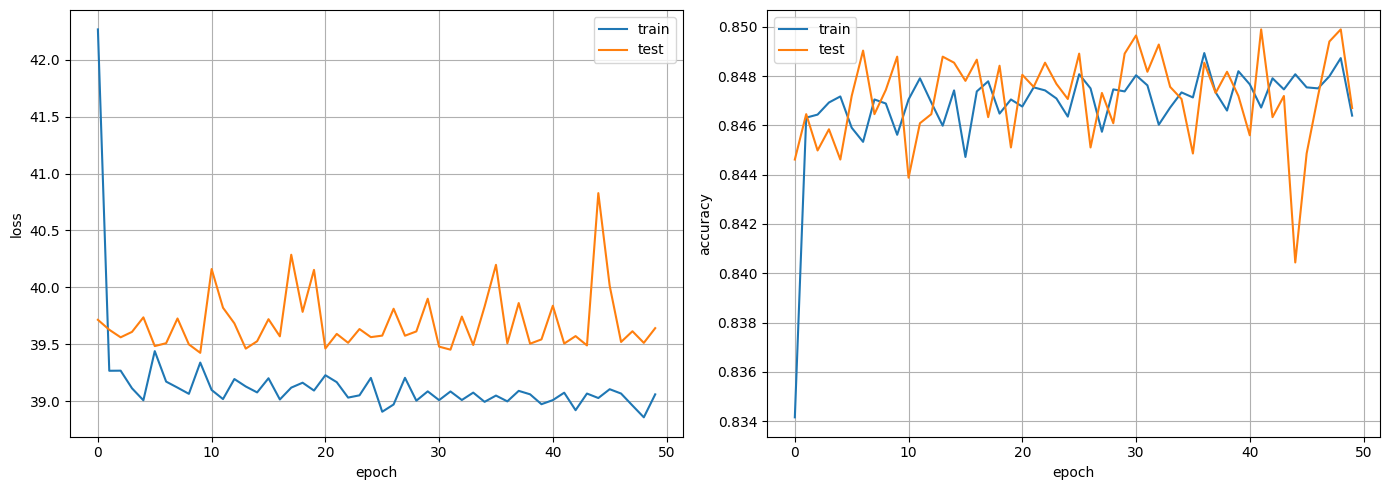

In [9]:
# Ваше решение (Code)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_loss, label='train')
axes[0].plot(test_loss, label='test')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()
axes[0].grid()

axes[1].plot(train_acc, label='train')
axes[1].plot(test_acc, label='test')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

__Задача 2.__ В предыдущей задаче мы убедились, что даже простая модель быстро достигает высокой точности на табличных данных — достаточно одной эпохи для получения высокого значения метрики. Однако в реальных задачах данные сложнее, и выбор гиперпараметров играет важную роль. В этом задании мы посмотрим, как размер батча влияет на качество обучения и скорость сходимости модели на примере датасета [`FashionMNIST`](https://www.kaggle.com/datasets/zalando-research/fashionmnist).

In [10]:
class FashionMNIST(Dataset):
    def __init__(self, root='.', download=True):
        transform = transforms.Compose([
            transforms.ToTensor()
        ])

        self.train_dataset = torchvision.datasets.FashionMNIST(
            root=root, train=True, download=download, transform=transform)
        self.test_dataset = torchvision.datasets.FashionMNIST(
            root=root, train=False, download=download, transform=transform)

In [11]:
FashionMNIST_dataset = FashionMNIST(root='.')

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.44MB/s]


In [12]:
fashion_classes = (
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
) 

def imshow_fashionmnist(img, ax=None, title=None):
    npimg = img.numpy().squeeze()  # (1, H, W) → (H, W)
    if ax is None:
        plt.imshow(npimg, cmap='gray')
        if title:
            plt.title(title)
        plt.axis('off')
    else:
        ax.imshow(npimg, cmap='gray')
        if title:
            ax.set_title(title)
        ax.axis('off')

def show_fashionmnist_samples(dataset, num_samples=20, rows=4, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    for idx, ax in zip(indices, axes):
        image, label = dataset[idx]
        imshow_fashionmnist(image, ax=ax, title=fashion_classes[label])

    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

Amount of train samples: 60000
Amount of test samples: 10000


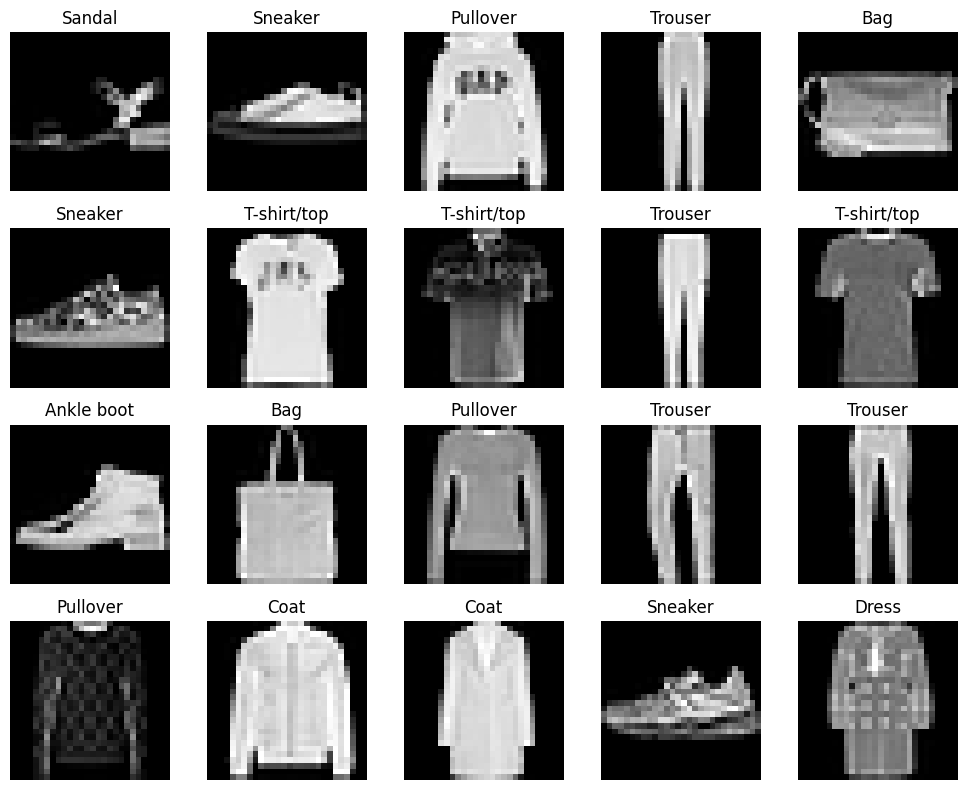

In [13]:
print(f"Amount of train samples: {len(FashionMNIST_dataset.train_dataset)}")
print(f"Amount of test samples: {len(FashionMNIST_dataset.test_dataset)}")

show_fashionmnist_samples(FashionMNIST_dataset.train_dataset)

__а) (1 балл)__ Рассмотрим более глубокую нейронную сеть, так как логистическая регрессия недостаточно хорошо приближает распределение данных в датасете F-MNIST. Реализуйте Multi-layer Perceptron (MLP), считая известным, что F-MNIST состоит из картинок размера 28*28, а число классов в нем равно 10:
1. [nn.Flatten()](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.flatten.Flatten.html#torch.nn.modules.flatten.Flatten)
2. [nn.Linear(input_size, hidden_size)](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)
3. [nn.ReLU()](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
4. [nn.Linear(hidden_size, num_classes)](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)

In [14]:
class MLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=256, num_classes=10):
        
        # YOUR CODE HERE
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        
        # YOUR CODE HERE
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)

        return x

__б) (1 балл)__ Модифицируйте метод `trainer`, добавив поддержку многоклассовой классификации.

In [15]:
def trainer(num_epochs, batch_size, model_class, criterion, optimizer_class,
            optimizer_params, dataset, device='cuda' if torch.cuda.is_available() else 'cpu'):

    """
    Универсальная функция для обучения моделей PyTorch.

    Параметры:
        num_epochs (int): Количество эпох обучения
        batch_size (int): Размер батча для DataLoader
        model_class (nn.Module): Класс модели
        criterion (nn.Module): Функция потерь
        optimizer_class (optim.Optimizer): Класс оптимизатора
        optimizer_params (dict): Параметры оптимизатора
        dataset (Dataset): Объект датасета
        device (str): Устройство для вычислений

    Возвращает:
        tuple: (train_losses, train_accuracies, test_losses, test_accuracies)
            train_losses: значения потерь на обучении
            train_accuracies: значения accuracy на обучении
            test_losses: значения потерь на тесте
            test_accuracies: значения accuracy на тесте
    """
    # Инициализация DataLoader
    train_loader = DataLoader(dataset.train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset.test_dataset, batch_size=batch_size, shuffle=False)

    # Инициализация модели
    model = model_class().to(device)
    optimizer = optimizer_class(model.parameters(), **optimizer_params)

    # Метрики
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    # Функции для train/test одной эпохи
    def train_epoch(epoch):
        model.train()
        
        # YOUR CODE HERE
        epoch_loss = 0
        epoch_correct = 0
        epoch_total = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device, dtype=torch.float32), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            preds = outputs.argmax(dim=1)
            epoch_correct += (preds == targets).sum().item()
            epoch_total += targets.size(0)

        
        train_loss = epoch_loss / len(train_loader)
        train_acc = epoch_correct/epoch_total


        return train_loss, train_acc 

    def test_epoch(epoch):
        model.eval()
        
        # YOUR CODE HERE
        epoch_loss = 0
        epoch_correct = 0
        epoch_total = 0

        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device, dtype=torch.float32), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                epoch_loss += loss.item()

                preds = outputs.argmax(dim=1)
                epoch_correct += (preds == targets).sum().item()
                epoch_total += targets.size(0)

        test_loss = epoch_loss / len(test_loader)
        test_acc = epoch_correct / epoch_total

        return test_loss, test_acc

    # Основной цикл обучения
    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_epoch(epoch)
        test_loss, test_acc = test_epoch(epoch)

        # Сохранение метрик
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        test_losses.append(test_loss)
        test_accuracies.append(test_acc)

        # Вывод статистики
        epoch_time = time.time() - start_time
        print(f'Epoch {epoch + 1} / {num_epochs} | '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
              f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | '
              f'Time: {epoch_time:.2f}s')

    return train_losses, train_accuracies, test_losses, test_accuracies

__в) (1 балл)__ Исследуйте влияние размера батча на качество модели. Используя предоставленный шаблон, постройте сравнительные графики значений функции потерь и значений метрики `accuracy` в зависимости от размера батча.


=== Training with batch size: 32 ===
Epoch 1 / 10 | Train Loss: 1.1306 | Train Acc: 0.67% | Test Loss: 0.7542 | Test Acc: 0.73% | Time: 10.46s
Epoch 2 / 10 | Train Loss: 0.6605 | Train Acc: 0.78% | Test Loss: 0.6248 | Test Acc: 0.79% | Time: 9.95s
Epoch 3 / 10 | Train Loss: 0.5695 | Train Acc: 0.81% | Test Loss: 0.5655 | Test Acc: 0.81% | Time: 9.95s
Epoch 4 / 10 | Train Loss: 0.5245 | Train Acc: 0.82% | Test Loss: 0.5312 | Test Acc: 0.82% | Time: 9.55s
Epoch 5 / 10 | Train Loss: 0.4974 | Train Acc: 0.83% | Test Loss: 0.5153 | Test Acc: 0.82% | Time: 9.60s
Epoch 6 / 10 | Train Loss: 0.4789 | Train Acc: 0.84% | Test Loss: 0.5013 | Test Acc: 0.83% | Time: 10.03s
Epoch 7 / 10 | Train Loss: 0.4651 | Train Acc: 0.84% | Test Loss: 0.4902 | Test Acc: 0.83% | Time: 9.90s
Epoch 8 / 10 | Train Loss: 0.4537 | Train Acc: 0.84% | Test Loss: 0.4753 | Test Acc: 0.83% | Time: 10.01s
Epoch 9 / 10 | Train Loss: 0.4441 | Train Acc: 0.85% | Test Loss: 0.4771 | Test Acc: 0.83% | Time: 10.16s
Epoch 10 / 10

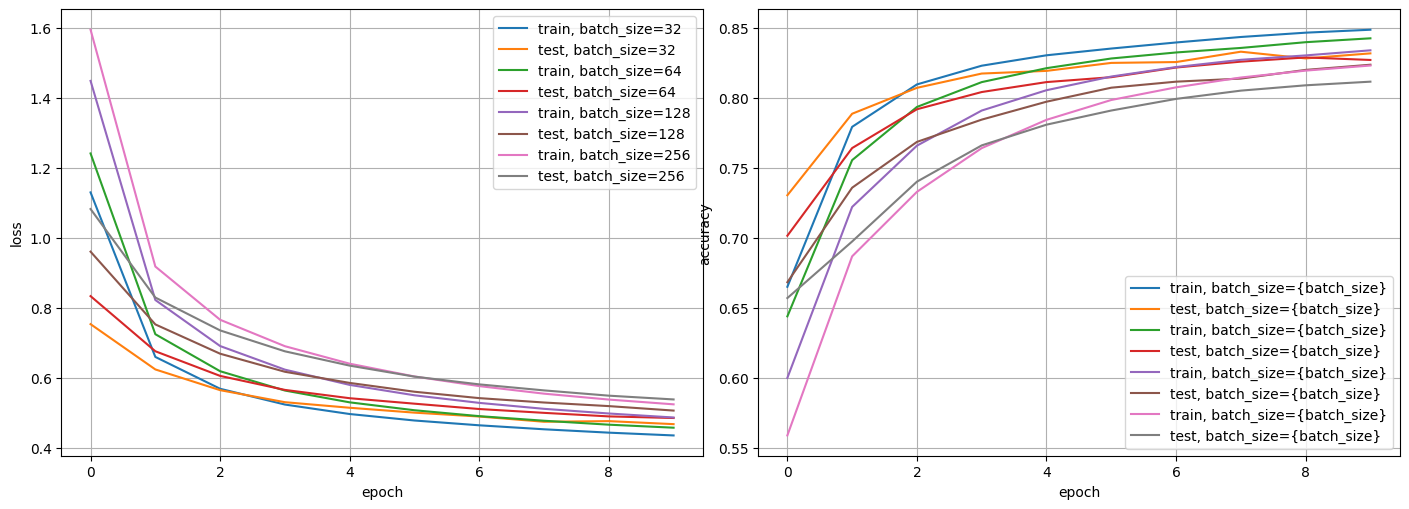

In [16]:
batch_sizes = [32, 64, 128, 256]

base_lr = 1e-3

train_acc_list=[]
test_acc_list=[]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for batch_size in batch_sizes:
    print(f"\n=== Training with batch size: {batch_size} ===")
    config = {
        'num_epochs': 10,
        'model_class': MLP,
        'criterion': nn.CrossEntropyLoss(reduction='mean'),
        'optimizer_class': SGD,
        'optimizer_params': {
            'lr': base_lr * np.sqrt(batch_size / 32),
            'momentum': 0.8,
            'weight_decay': 1e-4,
        },
        'dataset': FashionMNIST(),
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'batch_size': batch_size
    }

    train_loss, train_acc, test_loss, test_acc = trainer(**config)

    # YOUR CODE HERE

    axes[0].plot(train_loss, label=f'train, batch_size={batch_size}')
    axes[0].plot(test_loss, label=f'test, batch_size={batch_size}')

    axes[1].plot(train_acc, label='train, batch_size={batch_size}')
    axes[1].plot(test_acc, label='test, batch_size={batch_size}')

    plt.tight_layout()

axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()
axes[0].grid()

axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].legend()
axes[1].grid()

plt.show()

In [17]:
# Ваше решение (Code)

## Дополнительная часть (10 баллов)

In [4]:
import warnings
warnings.filterwarnings("ignore")

from torch import optim
from torchvision.models import resnet18

__Задача 2.__ В данной части будут рассмотрены не столь "игрушечные" датасеты, а уже проверенный временем бенчмарк для компьютерного зрения — связка из датасета [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) (картинки 32 $\times$ 32, 50,000 сэмплов train, 10,000 сэмплов test, 10 классов) и нейронной архитектуры [ResNet18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html). Так как курс посвящен оптимизации, то предлагается импортировать саму архитектуру (без непосредственной реализации) и работать с ней в парадигме "black-box" оптимизации — дан черный ящик в виде модели, хотим достичь наилучшего качества обучения.

In [5]:
class CIFAR10(Dataset):
    def __init__(self, root='.', download=True, normalize_mean=(0.5, 0.5, 0.5), normalize_std=(0.5, 0.5, 0.5)):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(normalize_mean, normalize_std)
        ])

        self.train_dataset = torchvision.datasets.CIFAR10(
            root = root,
            train = True,
            transform = transform,
            download = download,
        )
        self.test_dataset = torchvision.datasets.CIFAR10(
            root = root,
            train = False,
            transform = transform,
            download = download,
        )

    def __getitem__(self, index):
        """
        Получение одного элемента из набора данных
        """
        return self.dataset.__getitem__(index)

    def __len__(self):
        """
        Количество элементов в наборе данных
        """
        return self.dataset.__len__()

In [6]:
CIFAR10_dataset = CIFAR10(root='.')

100%|██████████| 170M/170M [00:03<00:00, 48.6MB/s] 


In [13]:
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img, ax=None, title=None):
    img = img / 2 + 0.5
    npimg = img.numpy()
    if ax is None:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))
        if title:
            plt.title(title)
        plt.axis('off')
    else:
        ax.imshow(np.transpose(npimg, (1, 2, 0)))
        if title:
            ax.set_title(title)
        ax.axis('off')


def show_dataset_samples(dataset, num_samples=20, rows=4, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    for i, ax in enumerate(zip(indices, axes)):
        image, label = dataset[i]
        imshow(image, ax=ax[1], title=classes[label])

    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

Amount of train samples: 50000
Amount of test samples: 10000


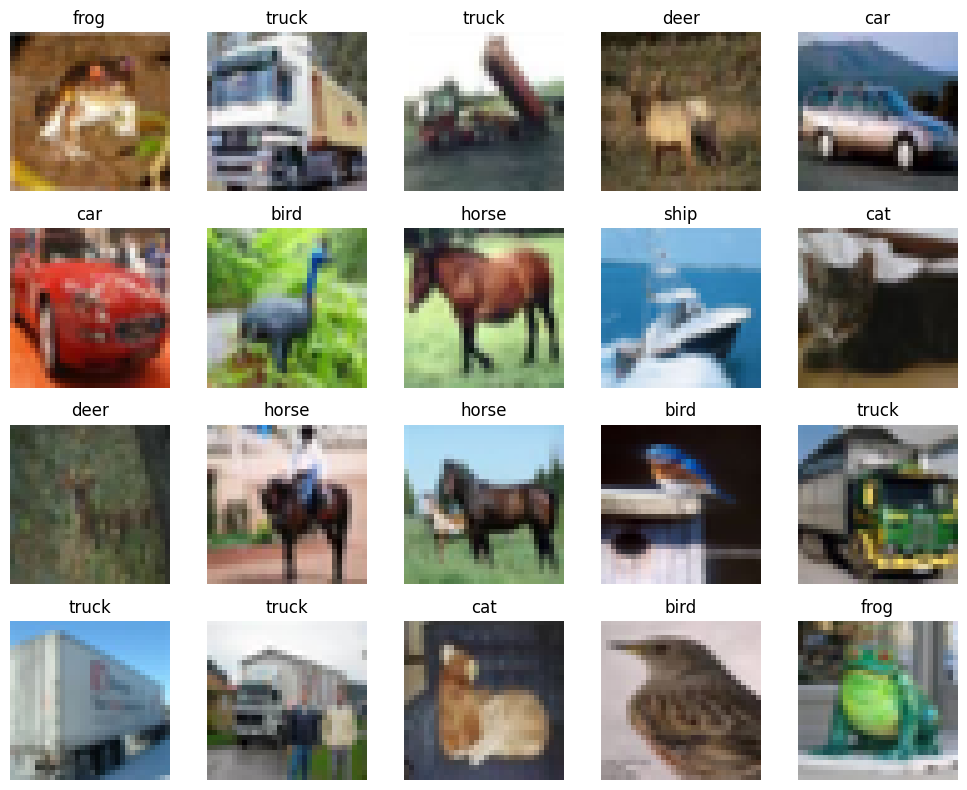

In [22]:
print(f"Amount of train samples: {len(CIFAR10_dataset.train_dataset)}")
print(f"Amount of test samples: {len(CIFAR10_dataset.test_dataset)}")

show_dataset_samples(CIFAR10_dataset.train_dataset)

Теперь проинициализируем сверточную модель `ResNet18` ([оригинальная статья](https://arxiv.org/abs/1512.03385), [реализация в torch](https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html)), для желающих разобраться, из каких слоев она состоит, добавлена функция `print_model_summary`, в которой перечислены все слои и число обучаемых параметров.

In [23]:
# Число классов в датасете - 10
resnet = resnet18(weights=None, num_classes=10)

In [24]:
def print_model_summary(model, input_size):
    def register_hook(module):
        def hook(module, input, output):
            class_name = str(module.__class__).split(".")[-1].split("'")[0]
            module_idx = len(summary)

            m_key = f"{class_name}-{module_idx+1}"
            summary[m_key] = {
                "input_shape": list(input[0].size()),
                "output_shape": list(output.size()),
                "nb_params": sum(p.numel() for p in module.parameters())
            }

        if not isinstance(module, nn.Sequential) and not isinstance(module, nn.ModuleList) and module != model:
            hooks.append(module.register_forward_hook(hook))

    summary = {}
    hooks = []

    model.apply(register_hook)

    model.eval()
    with torch.no_grad():
        model(torch.zeros(1, *input_size))

    for h in hooks:
        h.remove()

    print("----------------------------------------------------------------")

    line_new = "{:>20}  {:>25} {:>15}".format("Layer (type)", "Output Shape", "Param #")
    print(line_new)
    print("================================================================")

    total_params = 0

    for layer in summary:
        line_new = "{:>20}  {:>25} {:>15}".format(
            layer,
            str(summary[layer]["output_shape"]),
            "{0:,}".format(summary[layer]["nb_params"])
        )

        total_params += summary[layer]["nb_params"]

        print(line_new)

    print("================================================================")
    print(f"Total params: {total_params:,}")
    print("----------------------------------------------------------------")

# Входной размер картинки - (3, 32, 32), так как она RGB-шная
print_model_summary(resnet, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [1, 64, 16, 16]           9,408
       BatchNorm2d-2            [1, 64, 16, 16]             128
              ReLU-3            [1, 64, 16, 16]               0
         MaxPool2d-4              [1, 64, 8, 8]               0
            Conv2d-5              [1, 64, 8, 8]          36,864
       BatchNorm2d-6              [1, 64, 8, 8]             128
              ReLU-7              [1, 64, 8, 8]               0
            Conv2d-8              [1, 64, 8, 8]          36,864
       BatchNorm2d-9              [1, 64, 8, 8]             128
             ReLU-10              [1, 64, 8, 8]               0
       BasicBlock-11              [1, 64, 8, 8]          73,984
           Conv2d-12              [1, 64, 8, 8]          36,864
      BatchNorm2d-13              [1, 64, 8, 8]             128
             ReLU-14              [1, 6

__a) (5 баллов)__ Рассмотрите несколько типов `lr_scheduler` — планировщика скорости обучения, предоставляемых библиотекой `torch`:

1) [`LambdaLR`](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LambdaLR.html)

$$
lr_{epoch + 1} = lr_{base} \cdot \lambda(epoch + 1)
$$

2) [`ExponentialLR`](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ExponentialLR.html)

$$
lr_{epoch + 1} = \gamma \cdot lr_{epoch}
$$

3) [`ReduceLROnPlateau`](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html)

    Шаг уменьшается на фактор при достижении плато в функции ошибок.

4) [`CosineAnnealingLR`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html) 

$$
lr_{epoch + 1} = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})
    \left(1 + \cos \left(\frac{\pi (epoch + 1)}{T_{\max}}\right)\right)
$$

5) [`LinearLR`](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LinearLR.html)

$$
lr_{epoch + 1} = lr_{base} \cdot \left(\alpha + \left(1 - \alpha \right) \left(1 - \frac{epoch + 1}{T_{\max}}\right) \right)
$$

Для удобства дальнейшего использования предлагается функция `get_lr_schedule`.

In [7]:
def get_lr_schedule(model_class, optimizer_class, optimizer_params, scheduler_class, scheduler_params,
                    num_epochs=100, dummy_loss=None):
    """
    Возвращает список значений learning rate для заданного планировщика.

    Параметры:
        model_class (nn.Module): Модель
        optimizer_class (optim.Optimizer): Оптимизатор
        optimizer_params (dict): Параметры оптимизатора
        scheduler_class (optim.lr_scheduler): Планировщик скорости обучения
        scheduler_params (dict): Параметры планировщика
        num_epochs (int): Количество эпох для симуляции
        dummy_loss (list or None): Список значений потерь для ReduceLROnPlateau

    Возвращает:
        lrs (list): Список learning rate на каждой итерации
    """

    model = model_class()
    optimizer = optimizer_class(model.parameters(), **optimizer_params)
    scheduler = scheduler_class(optimizer, **scheduler_params)

    lrs = []

    for i in range(num_epochs):
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            loss = dummy_loss[i] if dummy_loss is not None else 1.0
            scheduler.step(loss)
        else:
            scheduler.step()

        lrs.append(optimizer.param_groups[0]['lr'])

    return lrs

Изобразите поведение от номера эпохи `lr_scheduler`: `ExponentialLR`, `ReduceLROnPlateau`, `CosineAnnealingLR`, `LinearLR` (используйте готовые реализации в `torch`).

In [26]:
# Простая модель
class DummyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(10, 2)

    def forward(self, x):
        return self.linear(x)

In [27]:
num_epochs = 100
dummy_losses = [1.0 / (i + 1) for i in range(num_epochs - 30)] + [0.0001 for j in range(30)]

# YOUR CODE HERE
lr_exponential = get_lr_schedule(DummyModel, SGD, {'lr': 0.1}, optim.lr_scheduler.ExponentialLR,
                                 {'gamma': 0.95}, num_epochs=num_epochs)

lr_plateau = get_lr_schedule(DummyModel, SGD, {'lr': 0.1}, optim.lr_scheduler.ReduceLROnPlateau,
                             {'mode': 'min', 'factor': 0.5, 'patience': 5},
                             num_epochs=num_epochs, dummy_loss=dummy_losses)

lr_cosine = get_lr_schedule(DummyModel, SGD, {'lr': 0.1}, optim.lr_scheduler.CosineAnnealingLR,
                            {'T_max': num_epochs}, num_epochs=num_epochs)

lr_linear = get_lr_schedule(DummyModel, SGD, {'lr': 0.1}, optim.lr_scheduler.LinearLR,
                            {'start_factor': 1.0, 'end_factor': 0.01, 'total_iters': num_epochs},
                            num_epochs=num_epochs)

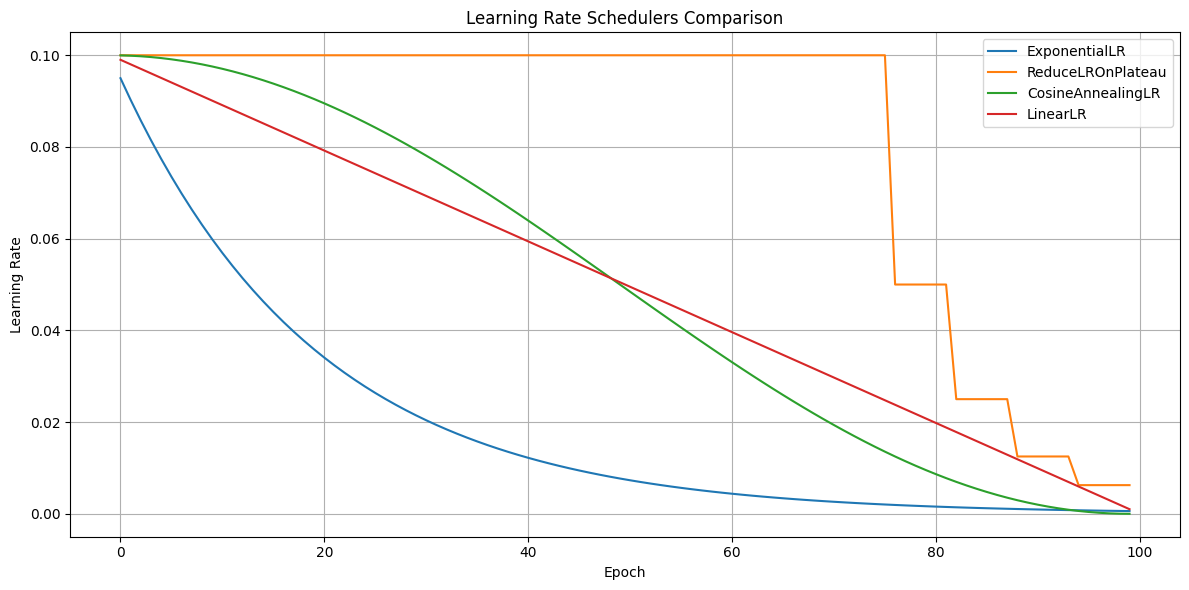

In [28]:
# Визуализация

plt.figure(figsize=(12, 6))
plt.plot(lr_exponential, label="ExponentialLR")
plt.plot(lr_plateau, label="ReduceLROnPlateau")
plt.plot(lr_cosine, label="CosineAnnealingLR")
plt.plot(lr_linear, label="LinearLR")

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedulers Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Применим соответствующие `lr_scheduler` для связки `CIFAR10` + `ResNet18`. Дополните функцию `trainer` с обновлением шага раз в эпоху.

In [9]:
def trainer(num_epochs, batch_size, model_class, criterion, optimizer_class=SGD, optimizer_params=None, 
            scheduler_class=None, scheduler_params=None, dataset=None,
            device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Универсальная функция для обучения моделей PyTorch.

    Параметры:
        num_epochs (int): Количество эпох обучения
        batch_size (int): Размер батча для DataLoader
        model_class (nn.Module): Класс модели
        criterion (nn.Module): Функция потерь
        optimizer_class (optim.Optimizer): Класс оптимизатора
        optimizer_params (dict): Параметры оптимизатора
        scheduler_class (optim.lr_scheduler): Класс планировщика скорости обучения
        scheduler_params (dict): Параметры планировщика скорости обучения
        dataset (Dataset): Объект датасета
        device (str): Устройство для вычислений

    Возвращает:
        model (nn.Module): Обученная модель
        metrics (dict): Словарь с логами
    """

    # Создаем загрузчики данных
    train_loader = DataLoader(dataset.train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset.test_dataset, batch_size=batch_size, shuffle=False)

    # Инициализируем модель, оптимизатор
    model = model_class.to(device)
    optimizer = optimizer_class(model.parameters(), **(optimizer_params or {}))

    # Инициализируем планировщик
    scheduler = None
    if scheduler_class is not None:
        scheduler = scheduler_class(optimizer, **(scheduler_params or {}))

    # Метрики
    metrics = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "learning_rates": []
    }

    def train_epoch(epoch):
        model.train()
        
        # YOUR CODE HERE
        epoch_loss = 0
        epoch_correct = 0
        epoch_total = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds = outputs.argmax(dim=1)
            epoch_correct += (preds == targets).sum().item()
            epoch_total += targets.size(0)

        train_loss = epoch_loss / len(train_loader)
        train_acc = epoch_correct / epoch_total
        
        return train_loss, train_acc 

    def test_epoch(epoch):
        model.eval()
        
        # YOUR CODE HERE
        epoch_loss = 0
        epoch_correct = 0
        epoch_total = 0

        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                epoch_loss += loss.item()
                preds = outputs.argmax(dim=1)
                epoch_correct += (preds == targets).sum().item()
                epoch_total += targets.size(0)

        test_loss = epoch_loss / len(test_loader)
        test_acc = epoch_correct / epoch_total

        return test_loss, test_acc

    # Обучение
    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_epoch(epoch)
        test_loss, test_acc = test_epoch(epoch)

        # Шаг планировщика
        
        # YOUR CODE HERE
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_loss)
            else:
                scheduler.step()

        # Сохраняем метрики
        metrics["train_loss"].append(train_loss)
        metrics["train_acc"].append(train_acc)
        metrics["test_loss"].append(test_loss)
        metrics["test_acc"].append(test_acc)
        metrics["learning_rates"].append(optimizer.param_groups[0]['lr'])

        # Логирование
        elapsed = time.time() - start_time
        print(f"Epoch {epoch + 1} / {num_epochs} | "
              f"LR: {metrics['learning_rates'][-1]:.2e} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}% | "
              f"Time: {elapsed:.2f}s")

    # Возвращаем модель и метрики
    return model, metrics

Посмотрим на работу одного `lr_scheduler`. Используйте его как пример.

In [30]:
resnet = resnet18(weights=None, num_classes=10)

config = {
    'num_epochs': 10,
    'batch_size': 128,
    'model_class': resnet,
    'criterion': nn.CrossEntropyLoss(reduction='mean'),
    'optimizer_class': SGD,
    'optimizer_params': {'lr': 1e-2, 'momentum': 0.8, 'weight_decay': 1e-4},
    'scheduler_class': optim.lr_scheduler.CosineAnnealingLR,
    'scheduler_params': {'T_max': 10, 'eta_min': 0.001},
    'dataset': CIFAR10_dataset,
    'device' : 'cuda',
}

# Запуск обучения
trained_resnet, metrics = trainer(**config)

Epoch 1 / 10 | LR: 9.78e-03 | Train Loss: 1.5440, Train Acc: 0.44% | Test Loss: 1.3130, Test Acc: 0.52% | Time: 29.20s
Epoch 2 / 10 | LR: 9.14e-03 | Train Loss: 1.1599, Train Acc: 0.59% | Test Loss: 1.1470, Test Acc: 0.59% | Time: 29.39s
Epoch 3 / 10 | LR: 8.15e-03 | Train Loss: 0.9306, Train Acc: 0.67% | Test Loss: 1.0870, Test Acc: 0.61% | Time: 29.13s
Epoch 4 / 10 | LR: 6.89e-03 | Train Loss: 0.7426, Train Acc: 0.74% | Test Loss: 1.0444, Test Acc: 0.65% | Time: 28.88s
Epoch 5 / 10 | LR: 5.50e-03 | Train Loss: 0.5724, Train Acc: 0.80% | Test Loss: 1.0534, Test Acc: 0.66% | Time: 29.53s
Epoch 6 / 10 | LR: 4.11e-03 | Train Loss: 0.3842, Train Acc: 0.87% | Test Loss: 1.1484, Test Acc: 0.66% | Time: 28.88s
Epoch 7 / 10 | LR: 2.85e-03 | Train Loss: 0.2088, Train Acc: 0.93% | Test Loss: 1.2135, Test Acc: 0.68% | Time: 29.41s
Epoch 8 / 10 | LR: 1.86e-03 | Train Loss: 0.0872, Train Acc: 0.98% | Test Loss: 1.2905, Test Acc: 0.68% | Time: 29.08s
Epoch 9 / 10 | LR: 1.22e-03 | Train Loss: 0.0342

Используя следующие параметры, постройте сравнительные графики функции ошибок и значений метрики для каждого `lr_scheduler`.

In [23]:
schedulers = {
    'CosineAnnealingLR': (optim.lr_scheduler.CosineAnnealingLR, {'T_max': 10, 'eta_min': 0.001}),
    'ExponentialLR': (optim.lr_scheduler.ExponentialLR, {'gamma': 0.9}),
    'ReduceLROnPlateau': (optim.lr_scheduler.ReduceLROnPlateau, {'mode': 'min', 'factor': 0.5, 'patience': 2}),
    'LinearLR': (optim.lr_scheduler.LinearLR, {'start_factor': 0.1, 'end_factor': 1.0, 'total_iters': 10}),
}

# YOUR CODE HERE
all_metrics = {}
for name, (sched_class, sched_params) in schedulers.items():
    print(f"\n=== Training with {name} scheduler ===")
    resnet = resnet18(weights=None, num_classes=10)
    config = {
        'num_epochs': 10,
        'batch_size': 128,
        'model_class': resnet,
        'criterion': nn.CrossEntropyLoss(reduction='mean'),
        'optimizer_class': SGD,
        'optimizer_params': {'lr': 1e-2, 'momentum': 0.8, 'weight_decay': 1e-4},
        'scheduler_class': sched_class,
        'scheduler_params': sched_params,
        'dataset': CIFAR10_dataset,
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    }
    _, m = trainer(**config)
    all_metrics[name] = m


=== Training with CosineAnnealingLR scheduler ===
Epoch 1 / 10 | LR: 9.78e-03 | Train Loss: 1.5325, Train Acc: 0.45% | Test Loss: 1.3024, Test Acc: 0.54% | Time: 30.48s
Epoch 2 / 10 | LR: 9.14e-03 | Train Loss: 1.1263, Train Acc: 0.60% | Test Loss: 1.0250, Test Acc: 0.64% | Time: 30.93s
Epoch 3 / 10 | LR: 8.15e-03 | Train Loss: 0.8959, Train Acc: 0.68% | Test Loss: 1.0075, Test Acc: 0.65% | Time: 30.84s
Epoch 4 / 10 | LR: 6.89e-03 | Train Loss: 0.7089, Train Acc: 0.75% | Test Loss: 1.1130, Test Acc: 0.63% | Time: 30.79s
Epoch 5 / 10 | LR: 5.50e-03 | Train Loss: 0.5293, Train Acc: 0.81% | Test Loss: 1.0107, Test Acc: 0.67% | Time: 31.40s
Epoch 6 / 10 | LR: 4.11e-03 | Train Loss: 0.3449, Train Acc: 0.88% | Test Loss: 1.1725, Test Acc: 0.66% | Time: 30.45s
Epoch 7 / 10 | LR: 2.85e-03 | Train Loss: 0.1762, Train Acc: 0.94% | Test Loss: 1.2098, Test Acc: 0.69% | Time: 30.97s
Epoch 8 / 10 | LR: 1.86e-03 | Train Loss: 0.0693, Train Acc: 0.98% | Test Loss: 1.2947, Test Acc: 0.70% | Time: 30.5

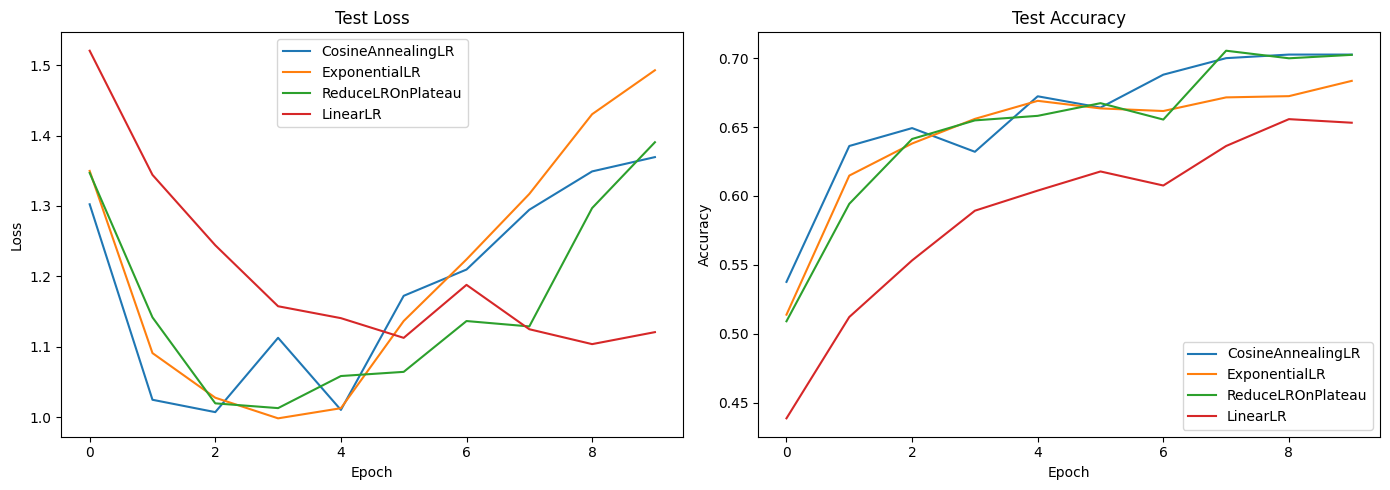

In [24]:
# Ваше решение (Code)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, m in all_metrics.items():
    axes[0].plot(m['test_loss'], label=name)
    axes[1].plot(m['test_acc'], label=name)
axes[0].set_title('Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()

Какой `lr_scheduler` показал себя лучше всего?

CosineAnnealingLR и ReduceLRONPlateau показали себя лучше всего, но Cosine менее склонен к переобучению

Посмотрим, чему научилась наша модель на картинках из тестового датасета. Возьмите для этого модель, которая достигла лучших показателей на тестовом датасете и передайте как параметр в предложенной функции визуализации.

In [10]:
resnet = resnet18(weights=None, num_classes=10)

config = {
    'num_epochs': 10,
    'batch_size': 128,
    'model_class': resnet,
    'criterion': nn.CrossEntropyLoss(reduction='mean'),
    'optimizer_class': SGD,
    'optimizer_params': {'lr': 1e-2, 'momentum': 0.8, 'weight_decay': 1e-4},
    'scheduler_class': optim.lr_scheduler.CosineAnnealingLR,
    'scheduler_params': {'T_max': 10, 'eta_min': 0.001},
    'dataset': CIFAR10_dataset,
    'device' : 'cuda',
}

trained_resnet, metrics = trainer(**config)

Epoch 1 / 10 | LR: 9.78e-03 | Train Loss: 1.5135, Train Acc: 0.46% | Test Loss: 1.2724, Test Acc: 0.54% | Time: 29.82s
Epoch 2 / 10 | LR: 9.14e-03 | Train Loss: 1.1152, Train Acc: 0.60% | Test Loss: 1.1350, Test Acc: 0.60% | Time: 29.46s
Epoch 3 / 10 | LR: 8.15e-03 | Train Loss: 0.8960, Train Acc: 0.68% | Test Loss: 1.0463, Test Acc: 0.64% | Time: 29.27s
Epoch 4 / 10 | LR: 6.89e-03 | Train Loss: 0.7118, Train Acc: 0.75% | Test Loss: 1.0055, Test Acc: 0.66% | Time: 30.38s
Epoch 5 / 10 | LR: 5.50e-03 | Train Loss: 0.5246, Train Acc: 0.82% | Test Loss: 1.0436, Test Acc: 0.67% | Time: 30.34s
Epoch 6 / 10 | LR: 4.11e-03 | Train Loss: 0.3416, Train Acc: 0.88% | Test Loss: 1.1461, Test Acc: 0.67% | Time: 31.17s
Epoch 7 / 10 | LR: 2.85e-03 | Train Loss: 0.1776, Train Acc: 0.94% | Test Loss: 1.2306, Test Acc: 0.68% | Time: 30.16s
Epoch 8 / 10 | LR: 1.86e-03 | Train Loss: 0.0698, Train Acc: 0.98% | Test Loss: 1.3012, Test Acc: 0.69% | Time: 30.96s
Epoch 9 / 10 | LR: 1.22e-03 | Train Loss: 0.0262

In [11]:
def show_model_predictions(model, dataset, num_samples=20, rows=4, cols=5, device='cpu'):
    model.to(device)
    model.eval()

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes = axes.flatten()

    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    for i, ax in enumerate(zip(indices, axes)):
        image, label = dataset[i]
        image_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_tensor)
            _, predicted = torch.max(output, 1)

        imshow(image, ax=ax[1], title=f"True: {classes[label]}\nPred: {classes[predicted.item()]}")

    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

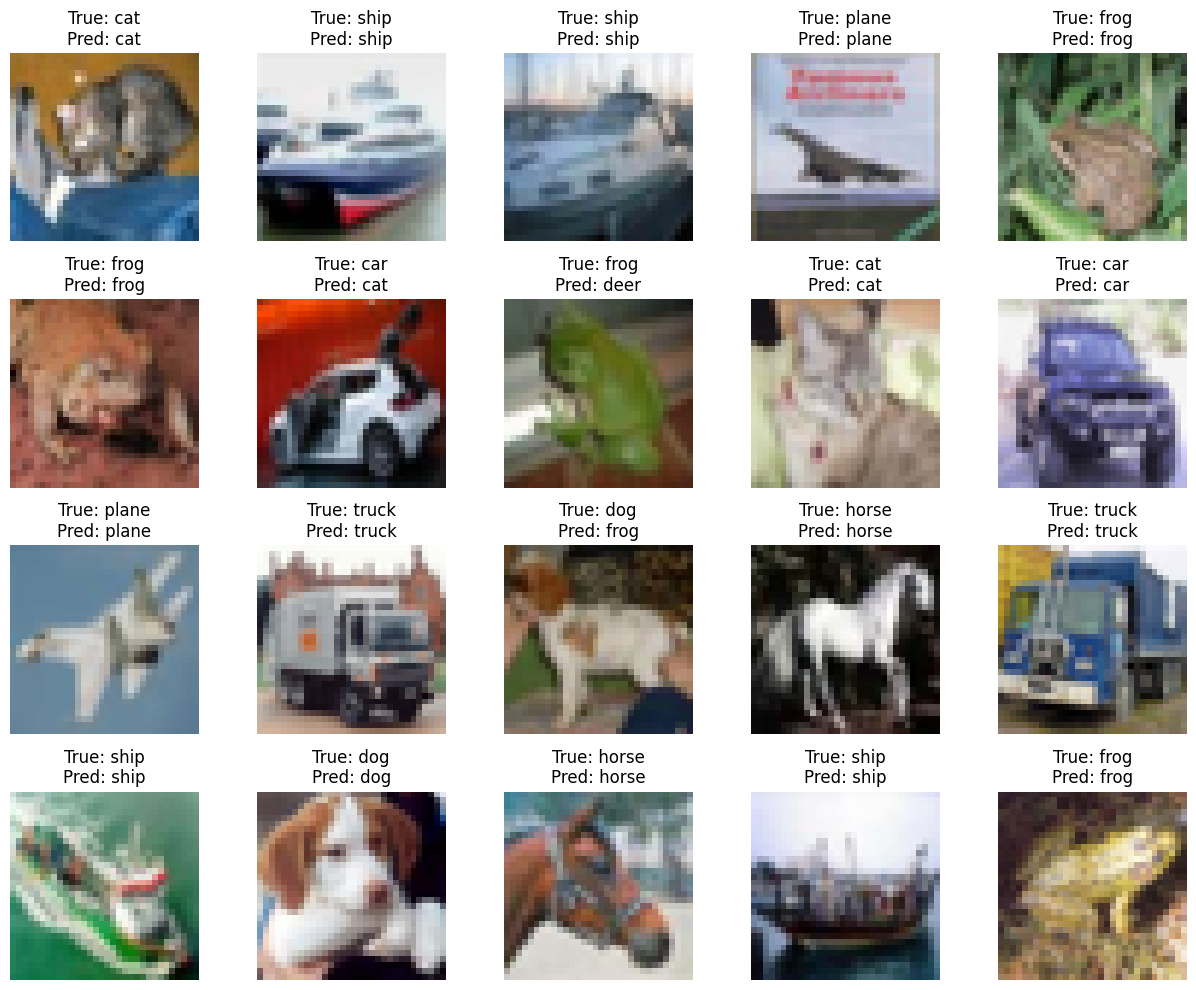

In [14]:
show_model_predictions(
    trained_resnet,
    CIFAR10_dataset.test_dataset,
    num_samples=20,
    rows=4,
    cols=5,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

__б) (5 баллов)__ Реализуйте две [техники](https://proceedings.neurips.cc/paper_files/paper/2020/file/c8cc6e90ccbff44c9cee23611711cdc4-Paper.pdf) перемешивания (shuffling-а), а именно: __RandomReshuffling__ и __ShuffleOnce__. Данные техники позволяют улучшить теоретическую и практическую сходимости алгоритмов. 

1. __RandomReshuffling__ — это метод, при котором данные перемешиваются случайным образом в начале каждой эпохи, обеспечивая более равномерное обновление параметров.

2. __ShuffleOnce__ выполняет перемешивание один раз в начале обучения, что снижает вычислительные затраты при сохранении эффективности сходимости.

Допишите классы, представленные ниже.

In [15]:
class RandomReshufflingSampler(torch.utils.data.Sampler):
    def __init__(self, data_source):
        self.data_source = data_source
        self.num_samples = len(data_source)
        self.indices = np.arange(self.num_samples)

    def __iter__(self):
        
        # YOUR CODE HERE
        np.random.shuffle(self.indices)
        return iter(self.indices.tolist())

    def __len__(self):
        
        # YOUR CODE HERE
        return self.num_samples

class ShuffleOnceSampler(torch.utils.data.Sampler):
    def __init__(self, data_source):
        self.data_source = data_source
        self.num_samples = len(data_source)
        self.indices = np.arange(self.num_samples)
        
        # YOUR CODE HERE
        np.random.shuffle(self.indices)

    def __iter__(self):
        
        # YOUR CODE HERE
        return iter(self.indices.tolist())
        
    def __len__(self):
        
        # YOUR CODE HERE
        return self.num_samples

Адаптируем функцию `trainer` для использования сэмплеров. Для этого необходимо поставить `shuffle=None`, чтобы убрать изначальное перемешивание и в качестве параметра `sampler=` передать необходимый сэмплер с параметрами.

In [16]:
def shuffled_trainer(num_epochs, batch_size, model_class, criterion, optimizer_class=SGD,
                     optimizer_params=None, scheduler_class=None, scheduler_params=None, dataset=None, 
                     sampler_class=None, sampler_params=None,
                     device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Универсальная функция для обучения моделей PyTorch.

    Параметры:
        num_epochs (int): Количество эпох обучения
        batch_size (int): Размер батча для DataLoader
        model_class (nn.Module): Класс модели
        criterion (nn.Module): Функция потерь
        optimizer_class (optim.Optimizer): Класс оптимизатора
        optimizer_params (dict): Параметры оптимизатора
        scheduler_class (optim.lr_scheduler): Класс планировщика скорости обучения
        scheduler_params (dict): Параметры планировщика скорости обучения
        dataset (Dataset): Объект датасета
        sampler_class (utils.data.Sampler): Класс кастомного sampler
        sampler_params (dict) Параметры sampler
        device (str): Устройство для вычислений

    Возвращает:
        model (nn.Module): Обученная модель
        metrics (dict): Словарь с логами
    """

    # Создаем загрузчики данных
    train_loader = DataLoader(
        dataset.train_dataset,
        batch_size=batch_size,
        shuffle=False,  # Используем кастомный sampler вместо shuffle
        sampler=sampler_class(dataset.train_dataset, **(sampler_params or {})) if sampler_class else None
    )
    test_loader = DataLoader(dataset.test_dataset, batch_size=batch_size, shuffle=False)
    
    # Инициализируем модель, оптимизатор
    model = model_class.to(device)
    optimizer = optimizer_class(model.parameters(), **(optimizer_params or {}))

    # Инициализируем планировщик
    scheduler = None
    if scheduler_class is not None:
        scheduler = scheduler_class(optimizer, **(scheduler_params or {}))

    # Метрики
    metrics = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "learning_rates": []
    }
    
    def train_epoch(epoch):
        model.train()
        
        # YOUR CODE HERE
        epoch_loss = 0
        epoch_correct = 0
        epoch_total = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds = outputs.argmax(dim=1)
            epoch_correct += (preds == targets).sum().item()
            epoch_total += targets.size(0)

        train_loss = epoch_loss / len(train_loader)
        train_acc = epoch_correct / epoch_total
        
        return train_loss, train_acc 

    def test_epoch(epoch):
        model.eval()
        
        # YOUR CODE HERE
        epoch_loss = 0
        epoch_correct = 0
        epoch_total = 0

        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                epoch_loss += loss.item()
                preds = outputs.argmax(dim=1)
                epoch_correct += (preds == targets).sum().item()
                epoch_total += targets.size(0)

        test_loss = epoch_loss / len(test_loader)
        test_acc = epoch_correct / epoch_total

        return test_loss, test_acc

    # Обучение
    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_epoch(epoch)
        test_loss, test_acc = test_epoch(epoch)

        # Шаг планировщика
        
        # YOUR CODE HERE
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_loss)
            else:
                scheduler.step()

        # Сохраняем метрики
        metrics["train_loss"].append(train_loss)
        metrics["train_acc"].append(train_acc)
        metrics["test_loss"].append(test_loss)
        metrics["test_acc"].append(test_acc)
        metrics["learning_rates"].append(optimizer.param_groups[0]['lr'])

        # Логирование
        elapsed = time.time() - start_time
        print(f"Epoch {epoch + 1} / {num_epochs} | "
              f"LR: {metrics['learning_rates'][-1]:.2e} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}% | "
              f"Time: {elapsed:.2f}s")

    # Возвращаем модель и метрики
    return model, metrics

Запустите обучение без `lr_scheduler` c теми же параметрами, что и ранее, для различных шаффлеров.

In [17]:
# Ваше решение (Code)
resnet_rr = resnet18(weights=None, num_classes=10)
config_rr = {
    'num_epochs': 10,
    'batch_size': 128,
    'model_class': resnet_rr,
    'criterion': nn.CrossEntropyLoss(reduction='mean'),
    'optimizer_class': SGD,
    'optimizer_params': {'lr': 1e-2, 'momentum': 0.8, 'weight_decay': 1e-4},
    'dataset': CIFAR10_dataset,
    'sampler_class': RandomReshufflingSampler,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}
_, metrics_rr = shuffled_trainer(**config_rr)

Epoch 1 / 10 | LR: 1.00e-02 | Train Loss: 1.5398, Train Acc: 0.44% | Test Loss: 1.3021, Test Acc: 0.53% | Time: 30.61s
Epoch 2 / 10 | LR: 1.00e-02 | Train Loss: 1.1286, Train Acc: 0.60% | Test Loss: 1.1207, Test Acc: 0.60% | Time: 31.56s
Epoch 3 / 10 | LR: 1.00e-02 | Train Loss: 0.9213, Train Acc: 0.68% | Test Loss: 1.0311, Test Acc: 0.64% | Time: 30.29s
Epoch 4 / 10 | LR: 1.00e-02 | Train Loss: 0.7493, Train Acc: 0.74% | Test Loss: 1.0138, Test Acc: 0.65% | Time: 30.99s
Epoch 5 / 10 | LR: 1.00e-02 | Train Loss: 0.6161, Train Acc: 0.78% | Test Loss: 0.9878, Test Acc: 0.67% | Time: 30.33s
Epoch 6 / 10 | LR: 1.00e-02 | Train Loss: 0.4941, Train Acc: 0.83% | Test Loss: 1.0393, Test Acc: 0.68% | Time: 30.86s
Epoch 7 / 10 | LR: 1.00e-02 | Train Loss: 0.3937, Train Acc: 0.86% | Test Loss: 1.2339, Test Acc: 0.65% | Time: 30.60s
Epoch 8 / 10 | LR: 1.00e-02 | Train Loss: 0.3130, Train Acc: 0.89% | Test Loss: 1.2588, Test Acc: 0.66% | Time: 30.81s
Epoch 9 / 10 | LR: 1.00e-02 | Train Loss: 0.2577

In [18]:
# Ваше решение (Code)
resnet_so = resnet18(weights=None, num_classes=10)
config_so = {
    'num_epochs': 10,
    'batch_size': 128,
    'model_class': resnet_so,
    'criterion': nn.CrossEntropyLoss(reduction='mean'),
    'optimizer_class': SGD,
    'optimizer_params': {'lr': 1e-2, 'momentum': 0.8, 'weight_decay': 1e-4},
    'dataset': CIFAR10_dataset,
    'sampler_class': ShuffleOnceSampler,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}
_, metrics_so = shuffled_trainer(**config_so)

Epoch 1 / 10 | LR: 1.00e-02 | Train Loss: 1.5117, Train Acc: 0.45% | Test Loss: 1.2792, Test Acc: 0.54% | Time: 31.75s
Epoch 2 / 10 | LR: 1.00e-02 | Train Loss: 1.1123, Train Acc: 0.60% | Test Loss: 1.1316, Test Acc: 0.60% | Time: 30.72s
Epoch 3 / 10 | LR: 1.00e-02 | Train Loss: 0.8704, Train Acc: 0.69% | Test Loss: 1.1372, Test Acc: 0.61% | Time: 31.07s
Epoch 4 / 10 | LR: 1.00e-02 | Train Loss: 0.6880, Train Acc: 0.76% | Test Loss: 1.2345, Test Acc: 0.61% | Time: 30.66s
Epoch 5 / 10 | LR: 1.00e-02 | Train Loss: 0.5443, Train Acc: 0.81% | Test Loss: 1.3167, Test Acc: 0.62% | Time: 30.88s
Epoch 6 / 10 | LR: 1.00e-02 | Train Loss: 0.4392, Train Acc: 0.84% | Test Loss: 1.4103, Test Acc: 0.63% | Time: 30.46s
Epoch 7 / 10 | LR: 1.00e-02 | Train Loss: 0.3544, Train Acc: 0.87% | Test Loss: 1.4405, Test Acc: 0.64% | Time: 30.72s
Epoch 8 / 10 | LR: 1.00e-02 | Train Loss: 0.2939, Train Acc: 0.89% | Test Loss: 1.4411, Test Acc: 0.65% | Time: 30.94s
Epoch 9 / 10 | LR: 1.00e-02 | Train Loss: 0.2280

Запустите с любым `lr_scheduler`. 

In [19]:
# Ваше решение (Code)
resnet_rr_s = resnet18(weights=None, num_classes=10)
_, metrics_rr_sched = shuffled_trainer(
    num_epochs=10, batch_size=128, model_class=resnet_rr_s,
    criterion=nn.CrossEntropyLoss(reduction='mean'),
    optimizer_class=SGD, optimizer_params={'lr': 1e-2, 'momentum': 0.8, 'weight_decay': 1e-4},
    scheduler_class=optim.lr_scheduler.CosineAnnealingLR, scheduler_params={'T_max': 10, 'eta_min': 0.001},
    dataset=CIFAR10_dataset, sampler_class=RandomReshufflingSampler
)

resnet_so_s = resnet18(weights=None, num_classes=10)
_, metrics_so_sched = shuffled_trainer(
    num_epochs=10, batch_size=128, model_class=resnet_so_s,
    criterion=nn.CrossEntropyLoss(reduction='mean'),
    optimizer_class=SGD, optimizer_params={'lr': 1e-2, 'momentum': 0.8, 'weight_decay': 1e-4},
    scheduler_class=optim.lr_scheduler.CosineAnnealingLR, scheduler_params={'T_max': 10, 'eta_min': 0.001},
    dataset=CIFAR10_dataset, sampler_class=ShuffleOnceSampler
)

Epoch 1 / 10 | LR: 9.78e-03 | Train Loss: 1.5205, Train Acc: 0.45% | Test Loss: 1.2432, Test Acc: 0.56% | Time: 30.67s
Epoch 2 / 10 | LR: 9.14e-03 | Train Loss: 1.1233, Train Acc: 0.60% | Test Loss: 1.0490, Test Acc: 0.63% | Time: 31.01s
Epoch 3 / 10 | LR: 8.15e-03 | Train Loss: 0.9011, Train Acc: 0.68% | Test Loss: 1.0545, Test Acc: 0.64% | Time: 30.58s
Epoch 4 / 10 | LR: 6.89e-03 | Train Loss: 0.7189, Train Acc: 0.74% | Test Loss: 0.9841, Test Acc: 0.66% | Time: 31.03s
Epoch 5 / 10 | LR: 5.50e-03 | Train Loss: 0.5416, Train Acc: 0.81% | Test Loss: 1.0445, Test Acc: 0.66% | Time: 30.58s
Epoch 6 / 10 | LR: 4.11e-03 | Train Loss: 0.3567, Train Acc: 0.88% | Test Loss: 1.0907, Test Acc: 0.68% | Time: 30.91s
Epoch 7 / 10 | LR: 2.85e-03 | Train Loss: 0.1865, Train Acc: 0.94% | Test Loss: 1.2189, Test Acc: 0.68% | Time: 31.14s
Epoch 8 / 10 | LR: 1.86e-03 | Train Loss: 0.0769, Train Acc: 0.98% | Test Loss: 1.2925, Test Acc: 0.69% | Time: 30.75s
Epoch 9 / 10 | LR: 1.22e-03 | Train Loss: 0.0289

Постройте сравнительные графики сходимости.

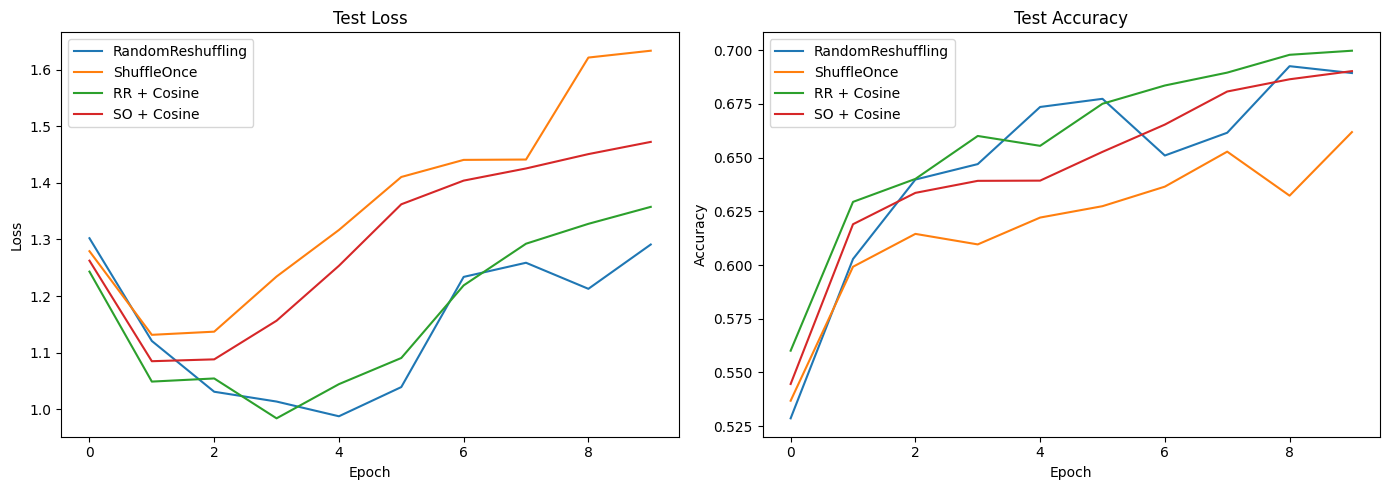

In [21]:
# Ваше решение (Code)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, m in [("RandomReshuffling", metrics_rr), ("ShuffleOnce", metrics_so),
                 ("RR + Cosine", metrics_rr_sched), ("SO + Cosine", metrics_so_sched)]:
    axes[0].plot(m['test_loss'], label=label)
    axes[1].plot(m['test_acc'], label=label)

axes[0].set_title('Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()

Дает ли данная техника улучшение?

Стало чуть получше